In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
S = ['High', 'Low', 'Charging'] #States [High -> 0 | Low -> 1 | Charging -> 2]
A = ['Search', 'Wait']#Action [Search -> 0 | Wait -> 1]

n_s = len(S) #number of states
n_a = len(A) #number of actions

In [3]:
P = np.zeros((n_s, n_a, n_s)) #Transition Matrix 3D (3 x 2 x 3)
R = np.zeros((n_s, n_a)) #Reward Matrix 2D (3 x 2)

In [4]:
P[0, 0, 0] = 0.7 # High -> Search -> High
P[0, 0, 1] = 0.3 # High -> Search -> Low

P[0, 1, 0] = 1.0 # High -> Wait -> High

P[1, 0, 0] = 0.4 # Low -> Search -> High
P[1, 0, 1] = 0.6 # Low -> Search -> Low

P[1, 1, 1] = 1.0 # Low -> Wait -> Low

P[2, 1, 0] = 1.0 # Charging -> Wait -> High

In [5]:
R[0, 0] = 4 # High and Search
R[0, 1] = 1 # High and Wait

R[1, 0] = -3 # Low and Search
R[1, 1] = 1 # Low and Wait

R[2, 1] = 0 # Charging and Wait

In [6]:
for s in range(n_s):
    for a in range(n_a):
        print(f"P[{S[s]}, {A[a]}] sum = {P[s, a, :].sum()}")

print("\nReward Matrix R : " )
print(R)

#Till here same as in Task - 01

P[High, Search] sum = 1.0
P[High, Wait] sum = 1.0
P[Low, Search] sum = 1.0
P[Low, Wait] sum = 1.0
P[Charging, Search] sum = 0.0
P[Charging, Wait] sum = 1.0

Reward Matrix R : 
[[ 4.  1.]
 [-3.  1.]
 [ 0.  0.]]


**Policy Evaluation Function (Used in Task - 01)**

In [11]:
def policy_evaluation(P, R, policy, g = 0.9, t = 1e-6):
    n_s = P.shape[0]
    V = np.zeros(n_s)

    iter = 0

    while True:
        delta = 0
        new_V = np.zeros(n_s)

        for s in range(n_s):
            a = policy[s]
            value = 0

            for s_next in range(n_s):
                prob = P[s, a, s_next]
                value += prob * (R[s, a] + g*V[s_next])
            
            new_V[s] = value

            delta = max(delta, abs(new_V[s] - V[s]))
            
        V = new_V
        iter += 1

        if delta < t:
            break

    print(f"Converged in {iter} iterations")
    return V

**Policy Improvement Function**

In [7]:
def policy_improvement(P, V, R, g = 0.9, old_policy = None):
    n_s = P.shape[0]
    n_a = P.shape[1]

    new_policy = np.zeros(n_s, dtype = int)

    for s in range(n_s):
        Q_v = []
        for a in range(n_a):
            q = 0
            for s_next in range(n_s):
                prob = P[s, a, s_next]
                q += prob * (R[s, a] + g*V[s_next])
            Q_v.append(q)
        new_policy[s] = np.argmax(Q_v)
    
    stable = True
    if old_policy is not None:
        stable = np.array_equal(new_policy, old_policy)
    
    return new_policy, stable

**Policy Iteration**

In [19]:
def policy_iteration(P, R, g = 0.9, t = 1e-6):
    n_s = P.shape[0]

    policy = np.ones(n_s, dtype = int) #Since they said to take intial policy as [wait wait wait] i.e [1 1 1]
    V_hist = []
    policy_hist = []
    iter = 0

    while True:
        print(f"Iteration {iter} : ")
        V = policy_evaluation(P, R, policy)
        V_hist.append(V.copy())
        policy_hist.append(policy.copy())

        print("Policy : ", [A[a] for a in policy])
        print("Values : ", V)
        print()

        new_policy, stable = policy_improvement(P, V, R, g, policy)
        iter += 1

        if stable:
            print("Policy Converged!!")
            break

        policy = new_policy
    
    return policy, V, V_hist, policy_hist

In [20]:
optimal_policy, V_star, V_hist, policy_hist = policy_iteration(P, R)

Iteration 0 : 
Converged in 133 iterations
Policy :  ['Wait', 'Wait', 'Wait']
Values :  [9.99999179 9.99999179 8.99999179]

Iteration 1 : 
Converged in 133 iterations
Policy :  ['Search', 'Wait', 'Wait']
Values :  [18.1080999   9.99999179 16.29728909]

Policy Converged!!


In [17]:
print("Final Optimal Policy : ")
for i in range(len(S)):
    print(f"{S[i]} -> {A[optimal_policy[i]]}")

print("\nOptimal Value Function : ")
for i in range(len(S)):
    print(f"V*({S[i]}) = {V_star[i]:.4f}")

Final Optimal Policy : 
High -> Search
Low -> Wait
Charging -> Wait

Optimal Value Function : 
V*(High) = 18.1081
V*(Low) = 10.0000
V*(Charging) = 16.2973


**Plot Value Convergence** 

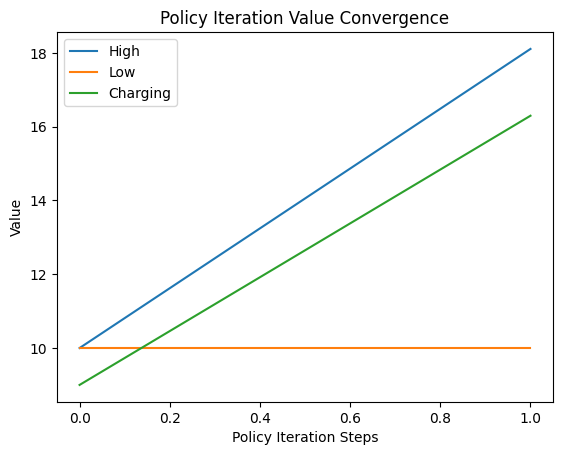

In [ ]:
V_hist = np.array(V_hist)

for i in range(len(S)):
    plt.plot(V_hist[:, i], label = S[i])

plt.xlabel("Policy Iteration Steps")
plt.ylabel("Value")
plt.title("Policy Iteration Value Convergence")
plt.legend()
plt.show()

# You will get all as linear since it converged in two iterations giving only two points, 
# and joining two points always forms a straight line

**Policy Evolution Table (Heap Map Style)**

In [26]:
policy_hist = np.array(policy_hist)

print("Policy Evolution Table : ")
for i in range(len(S)):
    row = [A[a] for a in policy_hist[:, i]]
    print(f"{S[i]} : {row[0]} (Iter 0) -> {row[1]} (Iter 1)")

Policy Evolution Table : 
High : Wait (Iter 0) -> Search (Iter 1)
Low : Wait (Iter 0) -> Wait (Iter 1)
Charging : Wait (Iter 0) -> Wait (Iter 1)
